In [ ]:
!pip install numpy==1.24.4 scipy==1.11.4 --quiet
import os
os.kill(os.getpid(), 9)  # Restart runtime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 17.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
xarray-einstats 0.9.0 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
blosc2 3.3.4 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
pymc 5.23.0 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1

In [1]:
!pip install gensim --quiet

import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import gensim
from gensim.models import Word2Vec

import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [6]:
DATA_URL = "/kaggle/input/sms-spam-collection-dataset/spam.csv"

df  = pd.read_csv(DATA_URL, encoding='latin-1')

In [7]:
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [12]:
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

In [15]:
print(df['label'].value_counts())
df['label'] = df['label'].map({'ham': 0, 'spam': 1})


label
ham     4825
spam     747
Name: count, dtype: int64


In [23]:
import re
import string
from bs4 import BeautifulSoup

def simple_tokenize(text):
    # Tokenize using regex to match words
    return re.findall(r'\b[a-zA-Z]+\b', text)

# Optional: You can still use NLTK for stopwords and lemmatization if they're not causing issues.
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', force=True)
nltk.download('wordnet', force=True)
nltk.download('omw-1.4', force=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = BeautifulSoup(text, "html.parser").get_text()            # remove HTML
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)             # remove URLs
    text = re.sub(r'\d+', '', text)                                 # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuation
    tokens = simple_tokenize(text)                                  # regex-based tokenization
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply on your dataset
df = df.rename(columns={'v1': 'label', 'v2': 'text'})
df['clean_text'] = df['text'].apply(preprocess)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [24]:
#  STEP 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['label'], test_size=0.2, random_state=42)


In [36]:
#  STEP 6a: BoW Representation
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

lr = LogisticRegression()
lr.fit(X_train_bow, y_train)
pred_bow = lr.predict(X_test_bow)

bow_acc = accuracy_score(y_test, pred_bow)
print("BoW Accuracy:", bow_acc)
print(classification_report(y_test, pred_bow))

BoW Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [35]:
# STEP 6b: TF-IDF Representation
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
# Train
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)
pred_tfidf = lr.predict(X_test_tfidf)
#eval
tf_score = accuracy_score(y_test, pred_tfidf)
print("📊 TF-IDF Results")
print("Accuracy:", tf_score)
print(classification_report(y_test, pred_tfidf))

📊 TF-IDF Results
Accuracy: 0.9488789237668162
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.65      0.77       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115



In [34]:
# ✅ STEP 6c: Word2Vec Representation
# Tokenize for Word2Vec
def simple_tokenize(text):
    return re.findall(r'\b[a-zA-Z]+\b', text)

# Tokenize for Word2Vec
train_tokens = [simple_tokenize(text) for text in X_train]
test_tokens = [simple_tokenize(text) for text in X_test]

# Remove stopwords
stop_words = set(stopwords.words('english'))
train_tokens = [[w for w in doc if w not in stop_words] for doc in train_tokens]
test_tokens = [[w for w in doc if w not in stop_words] for doc in test_tokens]

# Train Word2Vec
w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=1, workers=4)

# Function to average word vectors
def vectorize(tokens):
    vec = np.zeros(100)
    count = 0
    for word in tokens:
        if word in w2v_model.wv:
            vec += w2v_model.wv[word]
            count += 1
    return vec / count if count != 0 else vec

X_train_w2v = np.array([vectorize(doc) for doc in train_tokens])
X_test_w2v = np.array([vectorize(doc) for doc in test_tokens])

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_w2v, y_train)
pred_w2v = lr.predict(X_test_w2v)

print("🧠 Word2Vec Results")
vec_score=accuracy_score(y_test, pred_w2v)
print("Accuracy:",vec_score )
print(classification_report(y_test, pred_w2v))


🧠 Word2Vec Results
Accuracy: 0.8654708520179372
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


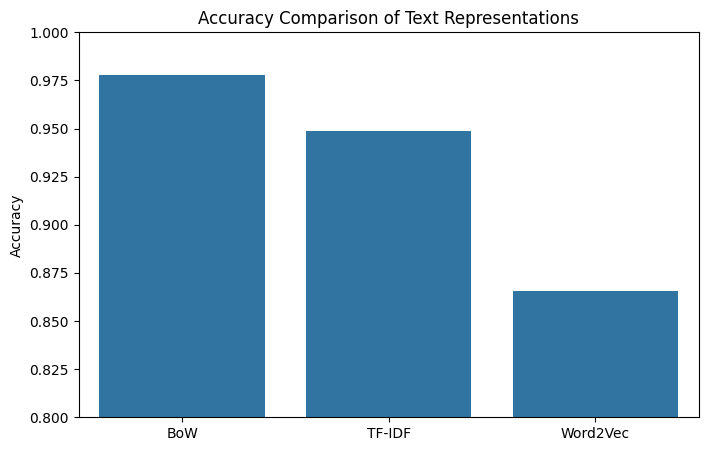

In [38]:
# Accuracy Comparison
import matplotlib.pyplot as plt
import seaborn as sns
methods = ['BoW', 'TF-IDF', 'Word2Vec']
accuracies = [bow_acc, tf_score, vec_score]

plt.figure(figsize=(8,5))
sns.barplot(x=methods, y=accuracies)
plt.title("Accuracy Comparison of Text Representations")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

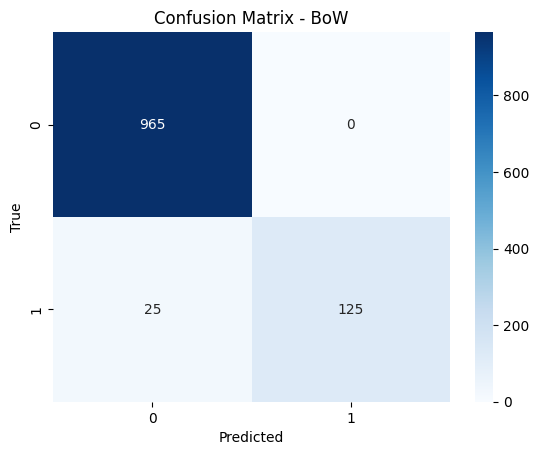

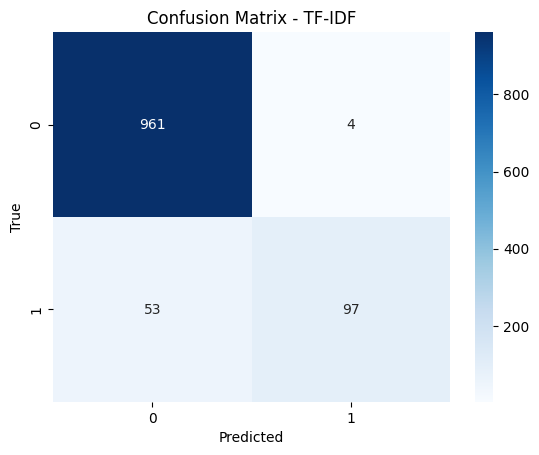

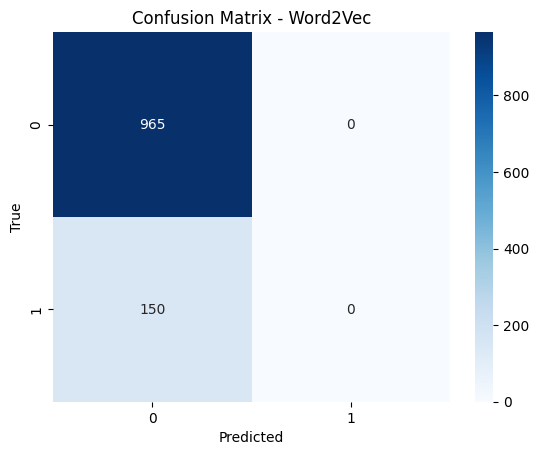

In [40]:
from sklearn.metrics import confusion_matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

plot_conf_matrix(y_test, pred_bow, 'BoW')
plot_conf_matrix(y_test, pred_tfidf, 'TF-IDF')
plot_conf_matrix(y_test, pred_w2v, 'Word2Vec')